In [27]:
import torch
import numpy as np
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchmetrics import ConfusionMatrix
from timeit import default_timer as timer
from tqdm.auto import tqdm
from mlxtend.plotting import plot_confusion_matrix
from torchvision import transforms

In [28]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device(device)
print(f"Using device: {device}")

Using device: cuda


In [29]:
# Hyperparameters
LR         = 0.005
BATCH_SIZE = 128
EPOCHS     = 50
HIDDEN     = 64  

In [30]:
df = pd.read_csv("../../datasets/icml_face_data.csv")

In [31]:
emotion_counts = df['emotion'].value_counts().sort_index()
emotion_classes = {
    0: "Angry", 1: "Disgust", 2: "Fear",
    3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"
}
class_names = [emotion_classes[i] for i in range(7)]

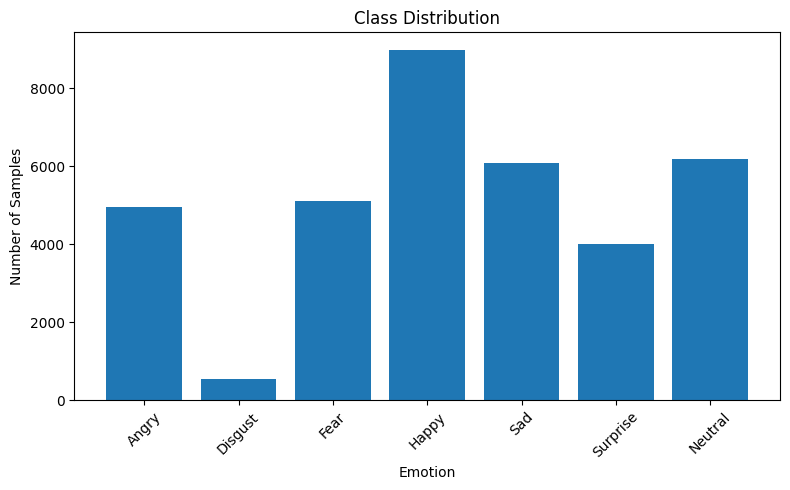

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(class_names, emotion_counts.values)
plt.title("Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df['emotion'], random_state=42
)

In [34]:
class CSVDataset(Dataset):
    def __init__(self, df, transform=None):
        self.data      = df
        self.transform = transform
        self.x = np.stack(
            self.data.iloc[:, -1].apply(
                lambda x: np.fromstring(x, sep=' ', dtype=np.float32)
            )
        ).reshape(-1, 48, 48)
        self.y = self.data.iloc[:, 0].values.astype(np.int64)
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        image = torch.tensor(self.x[idx]).unsqueeze(0)  # (1, 48, 48)
        label = self.y[idx]
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [35]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomGrayscale(p=0.1),                        
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
 
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [36]:
train_data = CSVDataset(train_df, transform=train_transform)
test_data  = CSVDataset(test_df,  transform=test_transform)

In [37]:
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(dataset=test_data,  batch_size=BATCH_SIZE, shuffle=False) 
print(f"Train batches: {len(train_dataloader)} | Test batches: {len(test_dataloader)}")

Train batches: 225 | Test batches: 57


In [41]:
# Helper functions
def eval_model(model, data_loader, loss_fn, accuracy_fn):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss  += loss_fn(y_pred, y)
            acc   += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc  /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc":  acc}

def print_train_time(start: float, end: float, device: torch.device = None):
    # Prints difference between start and end time
    total_time  = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    
    return  total_time


def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

In [42]:
# Class weights (for imbalance)
class_counts  = torch.tensor(
    [emotion_counts[i] for i in range(7)], dtype=torch.float
)
class_weights = (1.0 / class_counts)
class_weights = (class_weights / class_weights.sum() * 7).to(device)

# Build Models

In [43]:
class EmotionFERModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        h = hidden_units

        # Block 1 (48 → 24)
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, h, kernel_size=3, padding=1),
            nn.BatchNorm2d(h),
            nn.ReLU(),

            nn.Conv2d(h, h, kernel_size=3, padding=1),
            nn.BatchNorm2d(h),
            nn.ReLU(),

            nn.MaxPool2d(2)         # 48 → 24
        )

        # Block 2 (24 → 12)
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(h, h * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 2),
            nn.ReLU(),

            nn.Conv2d(h * 2, h * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 2),
            nn.ReLU(),

            nn.MaxPool2d(2)         # 24 → 12
        )

        # Block 3 (12 → 6)
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(h * 2, h * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 4),
            nn.ReLU(),

            nn.Conv2d(h * 4, h * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 4),
            nn.ReLU(),

            nn.MaxPool2d(2)         # 12 → 6
        )

        # Block 4 (6 → 3)
        self.conv_block_4 = nn.Sequential(
            nn.Conv2d(h * 4, h * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 8),
            nn.ReLU(),

            nn.Conv2d(h * 8, h * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 8),
            nn.ReLU(),

            nn.MaxPool2d(2),        # 6 → 3
            nn.Dropout2d(0.25)   
        )
        
        # Block 5 (3 → 3, NO MaxPool)
        self.conv_block_5 = nn.Sequential(
            nn.Conv2d(h * 8, h * 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 16),
            nn.ReLU(),
            nn.Dropout2d(0.25)  
        )
        

        # Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # 3×3 → 1×1
            nn.Flatten(),

            nn.Linear(h * 16, h * 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(h * 8, output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.conv_block_4(x)
        x = self.conv_block_5(x)
        x = self.classifier(x)
        return x

In [44]:
torch.manual_seed(42)
model = EmotionFERModel(input_shape=1, hidden_units=HIDDEN, output_shape=len(class_names)).to(device)
print(model)

EmotionFERModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Seque

In [45]:
loss_fn   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# functionizing training and testing loops

In [46]:
def train_step(model, data_loader, loss_fn, optimizer, accuracy_fn, device=device):
    train_loss, train_acc = 0, 0
    model.train()
 
    for X, y in data_loader:
        X, y = X.to(device), y.to(device)
 
        optimizer.zero_grad() 

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
 
        loss.backward()
        optimizer.step()
 
    train_loss /= len(data_loader)
    train_acc  /= len(data_loader)
    return train_loss, train_acc 

    

def test_step(data_loader, model, loss_fn, accuracy_fn, device=device):
    test_loss, test_acc = 0, 0
    model.eval()
 
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            test_loss += loss_fn(y_pred, y).item()
            test_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
 
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
    return test_loss, test_acc 
 

In [47]:
best_val_acc  = 0.0
best_epoch    = 0

In [48]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
start_time = timer()

for epoch in tqdm(range(EPOCHS)):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, accuracy_fn, device)
    test_loss,  test_acc  = test_step(test_dataloader, model, loss_fn, accuracy_fn, device)
    scheduler.step()
 
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
 
    # Save best checkpoint
    if test_acc > best_val_acc:
        best_val_acc = test_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  --> New best saved: {best_val_acc:.2f}% (epoch {best_epoch})")
 
end_time = timer()
print_train_time(start_time, end_time, device)
print(f"\nBest val accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")


  0%|          | 0/50 [00:00<?, ?it/s]


Epoch 1/50


  2%|▏         | 1/50 [00:26<21:30, 26.33s/it]

  --> New best saved: 2.52% (epoch 1)

Epoch 2/50


  4%|▍         | 2/50 [01:40<43:28, 54.35s/it]

...


Epoch 49/50


 98%|█████████▊| 49/50 [57:39<01:06, 66.47s/it]


Epoch 50/50


100%|██████████| 50/50 [58:42<00:00, 70.46s/it]

Train time on cuda: 3522.769 seconds

Best val accuracy: 68.29% at epoch 43


In [49]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

# evaluiation

In [50]:
results = eval_model(model, test_dataloader, loss_fn, accuracy_fn)
print(results)

{'model_name': 'EmotionFERModel', 'model_loss': 1.4076188802719116, 'model_acc': 68.28947368421052}


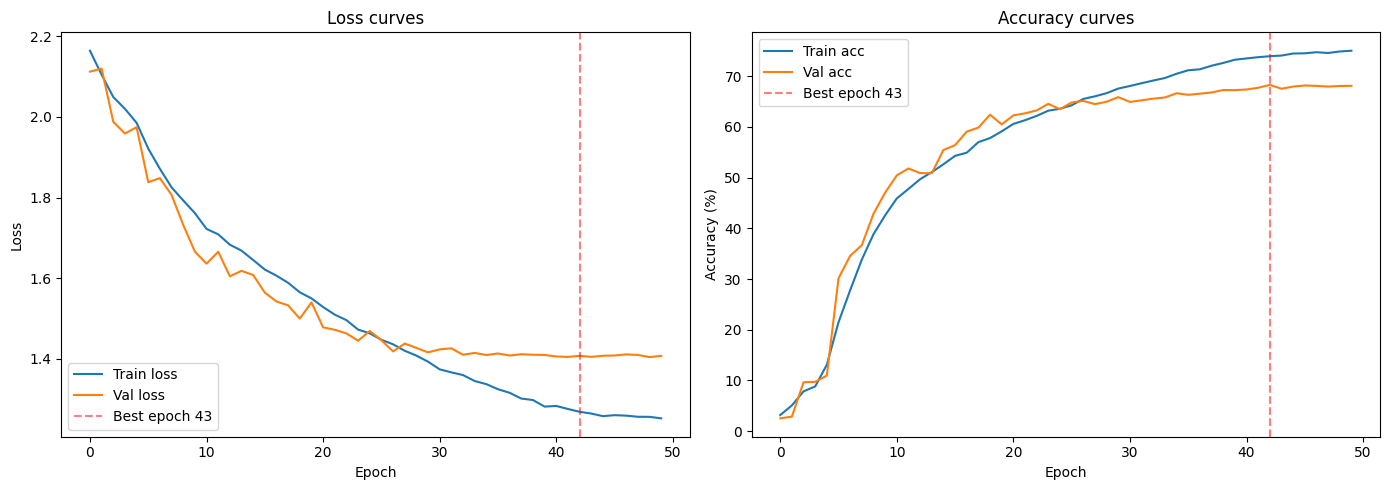

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
ax1.plot(history["train_loss"], label="Train loss")
ax1.plot(history["test_loss"],  label="Val loss")
ax1.set_title("Loss curves")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.axvline(best_epoch-1, color='red', linestyle='--', alpha=0.5, label=f"Best epoch {best_epoch}")
ax1.legend()
 
ax2.plot(history["train_acc"], label="Train acc")
ax2.plot(history["test_acc"],  label="Val acc")
ax2.set_title("Accuracy curves")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.axvline(best_epoch-1, color='red', linestyle='--', alpha=0.5, label=f"Best epoch {best_epoch}")
ax2.legend()
 
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

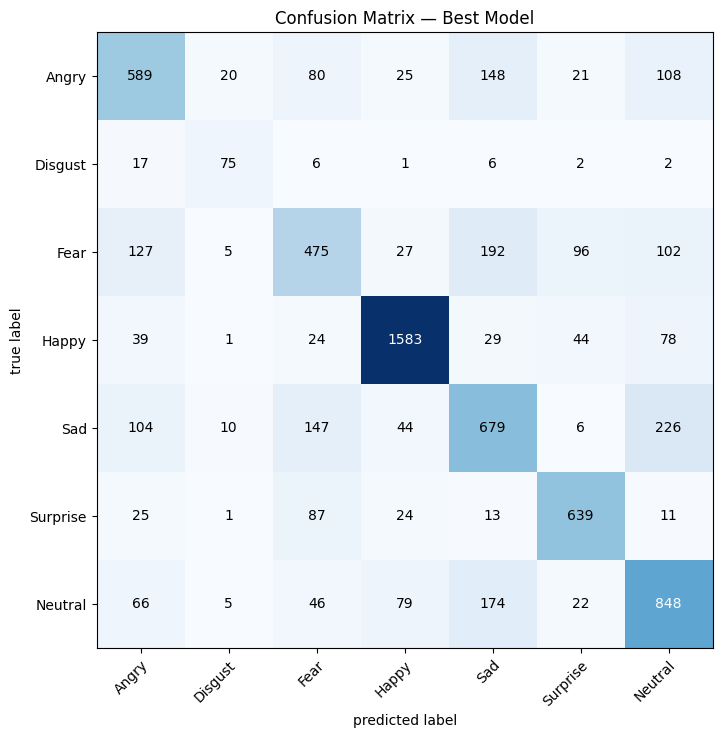

In [ ]:
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = torch.zeros(len(class_names), len(class_names), dtype=torch.int)
 
model.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y   = X.to(device), y.to(device)
        y_pred = model(X).argmax(dim=1)
        confmat_tensor += confmat(y_pred.cpu(), y.cpu())
 
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 8)
)
plt.title("Confusion Matrix — Best Model")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [54]:
sample_idx = 0
sample_img, sample_label = test_data[sample_idx]
print(f"Sample emotion: {class_names[sample_label]}")

Sample emotion: Happy


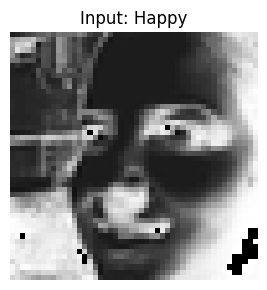

In [55]:
plt.figure(figsize=(3, 3))
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"Input: {class_names[sample_label]}")
plt.axis(False)
plt.tight_layout()
plt.show()

In [56]:
feature_maps = {}  # will store {block_name: activation_tensor}
 
def make_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook
 
# Attach a hook to the end of each conv block
hooks = [
    model.conv_block_1.register_forward_hook(make_hook("Block 1 (24x24)")),
    model.conv_block_2.register_forward_hook(make_hook("Block 2 (12x12)")),
    model.conv_block_3.register_forward_hook(make_hook("Block 3 (6x6)")),
    model.conv_block_4.register_forward_hook(make_hook("Block 4 (3x3)")),
    model.conv_block_5.register_forward_hook(make_hook("Block 5 (3x3)")),
]

In [57]:
model.eval()
with torch.inference_mode():
    input_tensor = sample_img.unsqueeze(0).to(device)  # (1, 1, 48, 48)
    output       = model(input_tensor)
    predicted    = output.argmax(dim=1).item()
 
print(f"Model predicted: {class_names[predicted]}")

Model predicted: Happy


In [58]:
for h in hooks:
    h.remove()

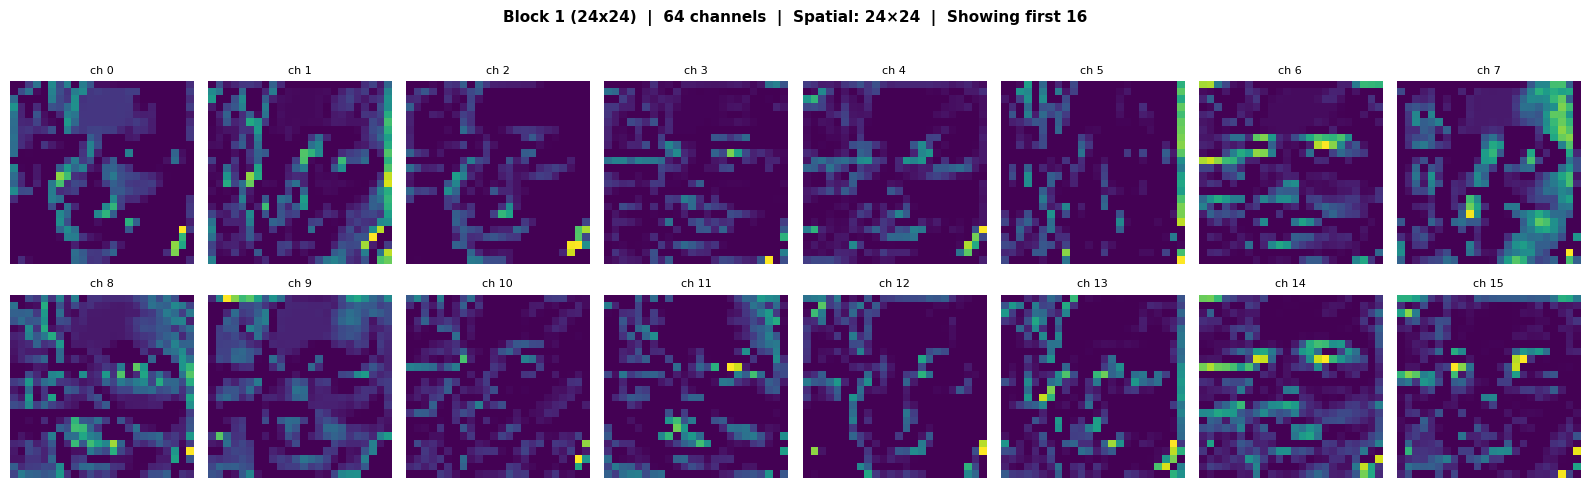

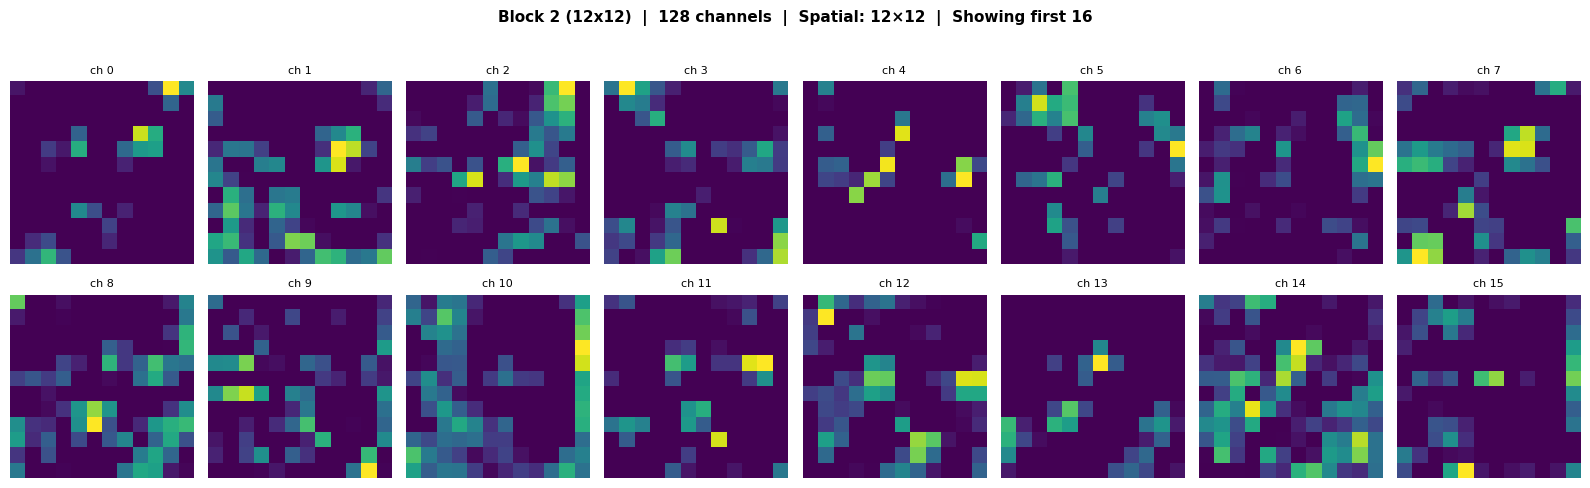

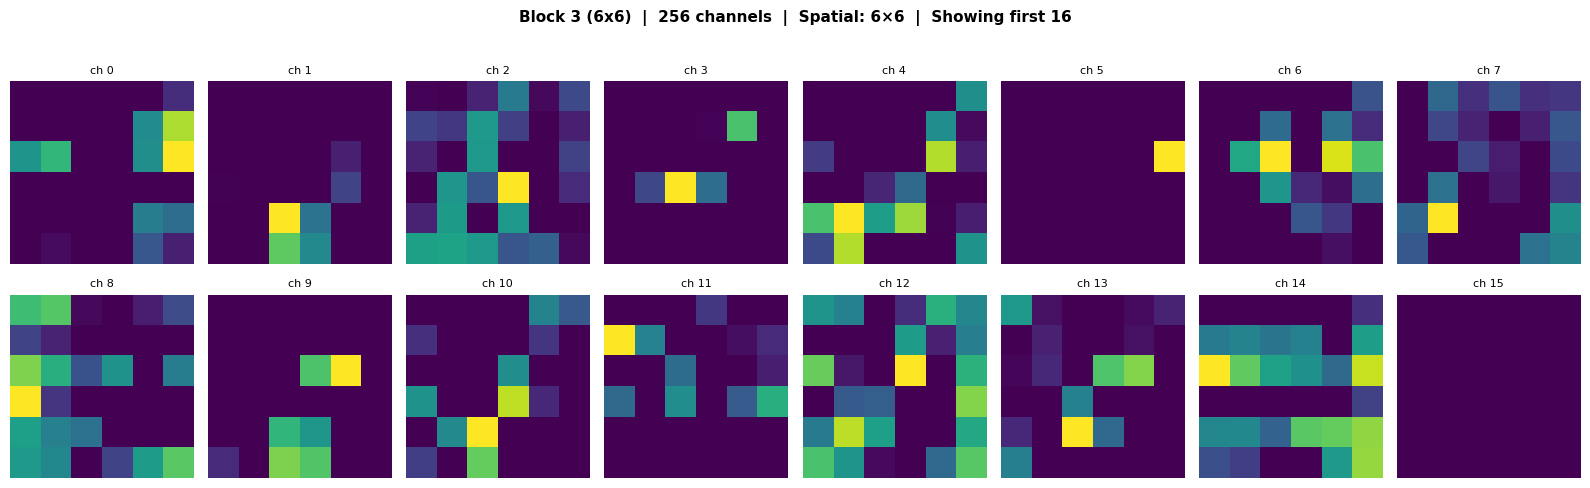

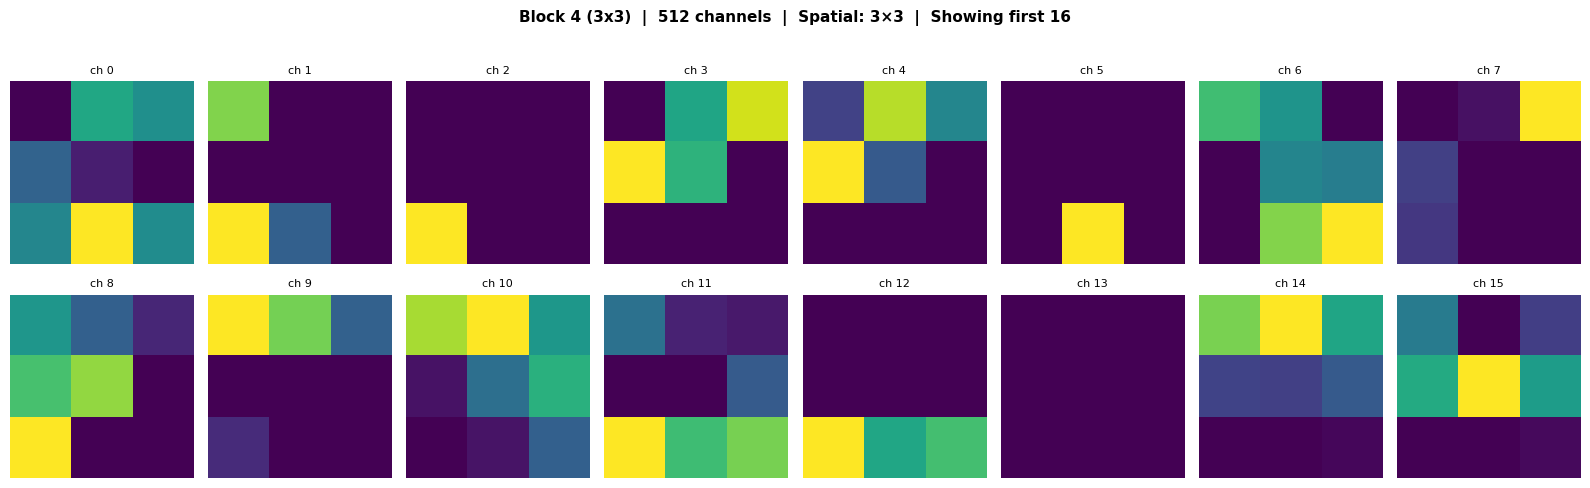

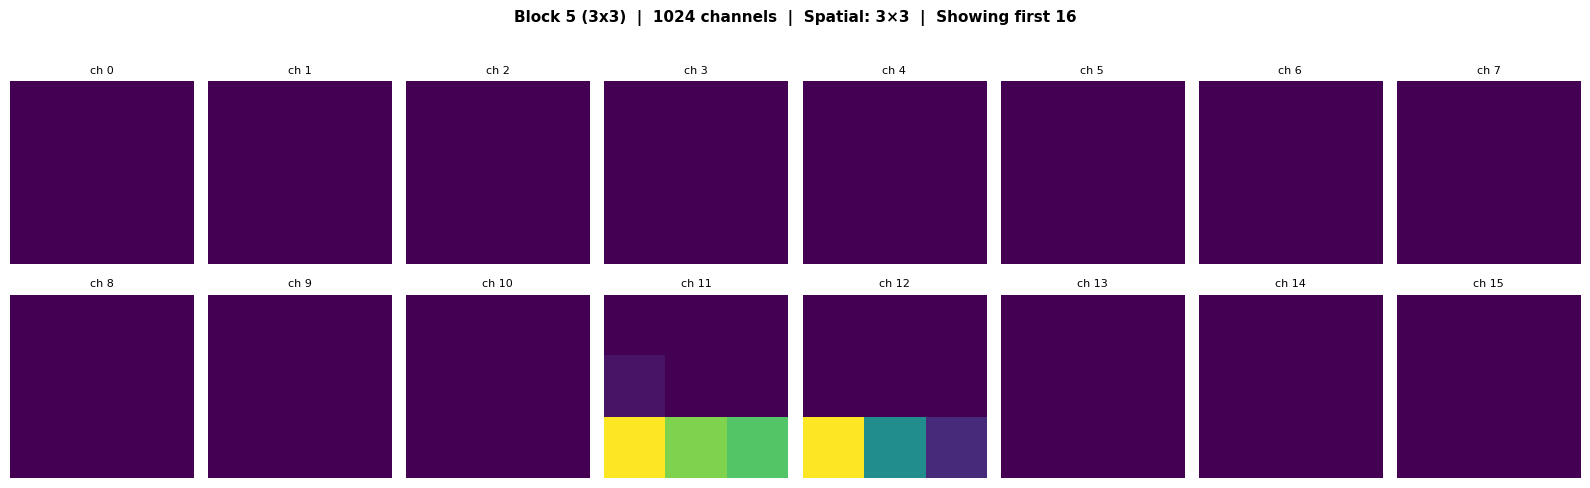

In [59]:
NUM_CHANNELS_TO_SHOW = 16  # how many channels to display per block
 
for block_name, fmap in feature_maps.items():
    # fmap shape: (1, C, H, W) — squeeze batch dim
    fmap = fmap.squeeze(0)          # → (C, H, W)
    num_channels = fmap.shape[0]
    n_show = min(NUM_CHANNELS_TO_SHOW, num_channels)
 
    fig, axes = plt.subplots(2, n_show // 2, figsize=(n_show, 5))
    fig.suptitle(
        f"{block_name}  |  {num_channels} channels  |  "
        f"Spatial: {fmap.shape[1]}×{fmap.shape[2]}  |  "
        f"Showing first {n_show}",
        fontsize=11, fontweight='bold', y=1.01
    )
 
    axes = axes.flatten()
    for i in range(n_show):
        channel = fmap[i].numpy()
 
        # Normalize each channel to [0, 1] for visibility
        ch_min, ch_max = channel.min(), channel.max()
        if ch_max - ch_min > 0:
            channel = (channel - ch_min) / (ch_max - ch_min)
 
        axes[i].imshow(channel, cmap='viridis')
        axes[i].set_title(f"ch {i}", fontsize=8)
        axes[i].axis(False)
 
    plt.tight_layout()
    plt.savefig(f"feature_map_{block_name.split()[0]}_{block_name.split()[1]}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

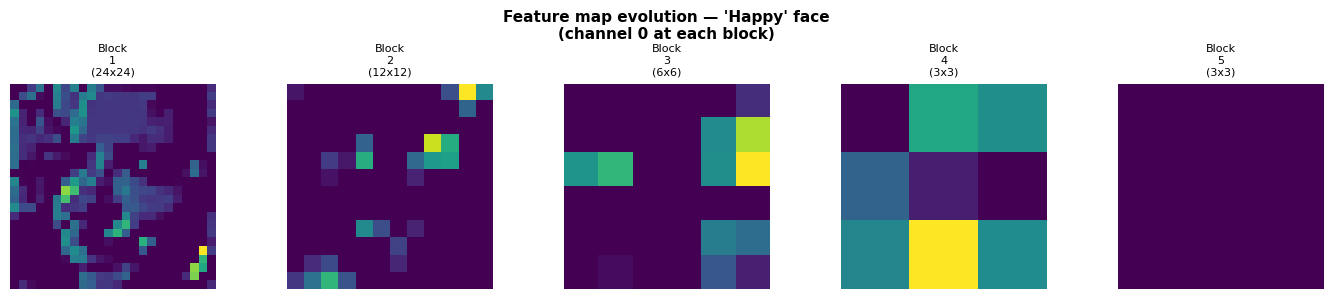

In [60]:
fig, axes = plt.subplots(1, len(feature_maps), figsize=(14, 3))
fig.suptitle(
    f"Feature map evolution — '{class_names[sample_label]}' face\n"
    f"(channel 0 at each block)",
    fontsize=11, fontweight='bold'
)
 
for ax, (block_name, fmap) in zip(axes, feature_maps.items()):
    fmap    = fmap.squeeze(0)
    channel = fmap[0].numpy()
    ch_min, ch_max = channel.min(), channel.max()
    if ch_max - ch_min > 0:
        channel = (channel - ch_min) / (ch_max - ch_min)
 
    ax.imshow(channel, cmap='viridis')
    ax.set_title(block_name.replace(" ", "\n"), fontsize=8)
    ax.axis(False)
 
plt.tight_layout()
plt.savefig("feature_map_summary.png", dpi=150, bbox_inches='tight')
plt.show()

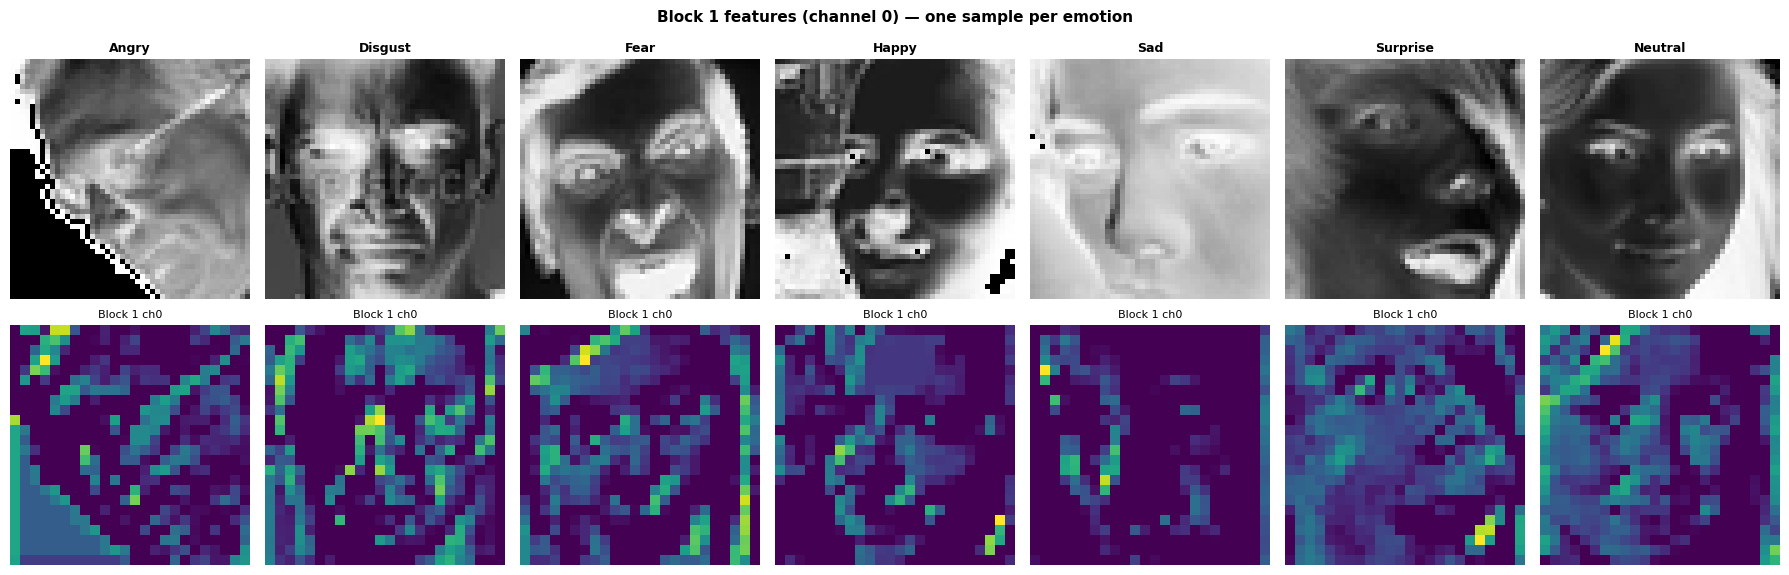

In [62]:
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
fig.suptitle("Block 1 features (channel 0) — one sample per emotion", fontsize=11, fontweight='bold')
 
for emotion_idx in range(7):
    # Find the first test sample of this emotion
    matches = [i for i, label in enumerate(test_data.y) if label == emotion_idx]
    if not matches:
        continue
    idx = matches[0]
    img, label = test_data[idx]
 
    # Register hook just for block 1
    block1_out = {}
    hook = model.conv_block_1.register_forward_hook(
        lambda m, i, o: block1_out.update({"out": o.detach().cpu()})
    )
 
    model.eval()
    with torch.inference_mode():
        model(img.unsqueeze(0).to(device))
    hook.remove()
 
    fmap    = block1_out["out"].squeeze(0)[0].numpy()
    ch_min, ch_max = fmap.min(), fmap.max()
    if ch_max - ch_min > 0:
        fmap = (fmap - ch_min) / (ch_max - ch_min)
 
    # Row 0: original image
    axes[0, emotion_idx].imshow(img.squeeze().numpy(), cmap='gray')
    axes[0, emotion_idx].set_title(class_names[emotion_idx], fontsize=9, fontweight='bold')
    axes[0, emotion_idx].axis(False)
 
    # Row 1: block 1 feature map
    axes[1, emotion_idx].imshow(fmap, cmap='viridis')
    axes[1, emotion_idx].set_title("Block 1 ch0", fontsize=8)
    axes[1, emotion_idx].axis(False)
 
axes[0, 0].set_ylabel("Input", fontsize=9)
axes[1, 0].set_ylabel("Block 1", fontsize=9)
 
plt.tight_layout()
plt.savefig("feature_map_per_emotion.png", dpi=150, bbox_inches='tight')
plt.show()